# Fair CPU Inference Benchmark

Measures real, single-transaction inference latency for all four
candidates on the same CPU, under an identical protocol. CNN-LSTM's
earlier GPU-only figure (Notebook 04c) is not representative of the
CPU-only deployment target, so it is re-measured here alongside the
others rather than reused as-is.

Requires the saved models from Notebooks 04, 04b, and 04c (`lgbm_model.pkl`,
`xgb_model.pkl`, the stacking components, and `cnn_lstm_model.keras`).


In [ ]:
import pandas as pd
import numpy as np
import time
import joblib
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

train = pd.read_parquet('../data/train_engineered.parquet')
train = train.sort_values('TransactionDT').reset_index(drop=True)

TARGET    = 'isFraud'
DROP_COLS = ['TransactionID', 'TransactionDT', TARGET]
DROP_COLS += train.select_dtypes('object').columns.tolist()
DROP_COLS  = [c for c in DROP_COLS if c in train.columns]
FEATURES   = [c for c in train.columns if c not in DROP_COLS]

X = train[FEATURES]
split_idx = int(len(train) * 0.80)
X_test = X.iloc[split_idx:]

# Single-row input, exactly as it would arrive in a real-time API call
single_row = X_test.iloc[[0]]
print(f'Single transaction shape: {single_row.shape}')

Single transaction shape: (1, 421)


## Benchmark Function

20 warm-up predictions are discarded before timing 200 runs, to avoid
measuring one-time initialization cost. Mean, median, p95, and max are
reported -- p95 matters more than mean for a real-time SLA, since it
reflects worst-case latency a transaction might actually experience.


In [10]:
N_WARMUP = 20
N_RUNS   = 200

def benchmark_predict(predict_fn, input_row, name):
    """Time N_RUNS single-row predictions on CPU. Returns dict of stats."""
    # Warm-up (not timed)
    for _ in range(N_WARMUP):
        predict_fn(input_row)

    times_ms = []
    for _ in range(N_RUNS):
        start = time.perf_counter()
        predict_fn(input_row)
        times_ms.append((time.perf_counter() - start) * 1000)

    times_ms = np.array(times_ms)
    result = {
        'model': name,
        'mean_ms': times_ms.mean(),
        'median_ms': np.median(times_ms),
        'p95_ms': np.percentile(times_ms, 95),
        'max_ms': times_ms.max()
    }
    print(f'{name:20s} mean={result["mean_ms"]:6.2f}ms  '
          f'median={result["median_ms"]:6.2f}ms  '
          f'p95={result["p95_ms"]:6.2f}ms  '
          f'max={result["max_ms"]:6.2f}ms')
    return result

benchmark_results = []

## LightGBM & XGBoost


In [11]:
lgbm_model = joblib.load('../models/lgbm_model.pkl')
xgb_model  = joblib.load('../models/xgb_model.pkl')

benchmark_results.append(
    benchmark_predict(lambda row: lgbm_model.predict_proba(row), single_row, 'LightGBM')
)
benchmark_results.append(
    benchmark_predict(lambda row: xgb_model.predict_proba(row), single_row, 'XGBoost')
)

LightGBM             mean=  6.72ms  median=  6.53ms  p95=  8.38ms  max= 13.07ms
XGBoost              mean= 27.78ms  median= 29.86ms  p95= 35.37ms  max=193.88ms


## Stacking Ensemble

Every prediction runs all 3 base learners sequentially, then a scaler and
meta-learner -- structurally slower than a single GBDT, not an
implementation inefficiency.


In [ ]:
lgbm_stack = joblib.load('../models/lightgbm_full.pkl')
xgb_stack  = joblib.load('../models/xgboost_full.pkl')
catboost_stack = joblib.load('../models/catboost_full.pkl')
meta_learner   = joblib.load('../models/meta_learner.pkl')
meta_scaler    = joblib.load('../models/meta_scaler.pkl')

def stacking_predict(row):
    """Full stacking inference pipeline: 3 base models -> scale -> meta-learner."""
    preds = np.array([
        lgbm_stack.predict_proba(row)[:, 1],
        xgb_stack.predict_proba(row)[:, 1],
        catboost_stack.predict_proba(row)[:, 1]
    ]).T
    preds_scaled = meta_scaler.transform(preds)
    return meta_learner.predict_proba(preds_scaled)

benchmark_results.append(
    benchmark_predict(stacking_predict, single_row, 'Stacking (3 models)')
)

Stacking (3 models)  mean= 74.06ms  median= 74.47ms  p95= 95.75ms  max=203.52ms


## CNN-LSTM

Loaded and benchmarked locally on the same CPU as the others, superseding
the earlier GPU-only figure from Notebook 04c.


In [ ]:
cnn_model = tf.keras.models.load_model('../models/cnn_lstm_model.keras')

# CNN-LSTM expects scaled, 3D input: (samples, timesteps, 1)
# Refit the scaler on the same training data used in Notebook 04c
X_train_cnn = X.iloc[:split_idx]
cnn_scaler = StandardScaler()
cnn_scaler.fit(X_train_cnn.fillna(0))

single_row_scaled = cnn_scaler.transform(single_row.fillna(0))
single_row_3d = single_row_scaled.reshape(1, single_row_scaled.shape[1], 1)

def cnn_predict(row_3d):
    return cnn_model.predict(row_3d, verbose=0)

benchmark_results.append(
    benchmark_predict(cnn_predict, single_row_3d, 'CNN-LSTM (CPU)')
)
print('\nNote: this is now measured on the SAME CPU as LightGBM/XGBoost/Stacking above --')
print('a fair comparison, unlike the earlier 84.0ms GPU figure from Notebook 04c.')


CNN-LSTM (CPU)       mean=243.00ms  median=254.47ms  p95=348.64ms  max=695.35ms

Note: this is now measured on the SAME CPU as LightGBM/XGBoost/Stacking above --
a fair comparison, unlike the earlier 84.0ms GPU figure from Notebook 04c.


## Comparison

In [14]:
results_df = pd.DataFrame(benchmark_results)
results_df['meets_300ms'] = results_df['mean_ms'] < 300

print('=== Inference Time Comparison (CPU, except CNN-LSTM on GPU) ===\n')
print(results_df.to_string(index=False))

results_df.to_csv('../reports/inference_benchmark.csv', index=False)
print('\nSaved: reports/inference_benchmark.csv')

=== Inference Time Comparison (CPU, except CNN-LSTM on GPU) ===

              model    mean_ms  median_ms     p95_ms   max_ms  meets_300ms
           LightGBM   6.715679     6.5290   8.381330  13.0699         True
            XGBoost  27.784385    29.8579  35.367365 193.8801         True
Stacking (3 models)  74.063834    74.4675  95.754790 203.5243         True
     CNN-LSTM (CPU) 242.999520   254.4664 348.639565 695.3525         True

Saved: reports/inference_benchmark.csv


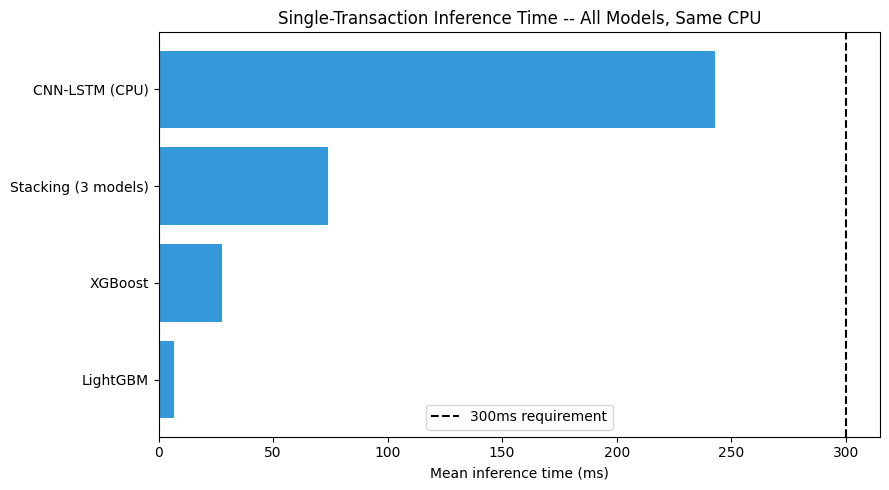

Saved: reports/inference_benchmark.png


: 

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(results_df['model'], results_df['mean_ms'], color='#3498db')
ax.axvline(300, color='black', linestyle='--', label='300ms requirement')
ax.set_xlabel('Mean inference time (ms)')
ax.set_title('Single-Transaction Inference Time -- All Models, Same CPU')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/inference_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reports/inference_benchmark.png')
